# Experimento de persistencia: Parquet vs Feather en Pylondrina

En este notebook se analizan los resultados del experimento comparativo entre **Parquet** y **Feather v2** como backends de persistencia para datasets Golondrina.

El objetivo es determinar si Feather puede **reemplazar o complementar** a Parquet bajo el patrón real de uso del módulo:

- el backend se usa principalmente para **write/read**;
- el procesamiento posterior ocurre en memoria;
- el artefacto persistido considera **datos + sidecar**;
- la **correctitud** del roundtrip es condición necesaria antes de comparar desempeño.

La regla de decisión adoptada fue:

1. Verificar correctitud.
2. Resumir por `(configuración, backend)` usando **mediana** e **IQR** sobre las 5 repeticiones medidas.
3. Calcular, para cada configuración, los ratios de Feather respecto a Parquet:
   - `r_time`
   - `r_size`
4. Calcular el score por configuración:
   - `score = 0.7 * r_time + 0.3 * r_size`
5. Calcular el **Score_global** como promedio de los 9 scores.
6. Aceptar a Feather como ganador solo si:
   - `Score_global < 1`
   - y además cumple la restricción de RAM en configuraciones exigentes.


In [2]:
from __future__ import annotations

import json
from pathlib import Path
import sys

REPO_ROOT = Path("../../..").resolve()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))
DATA_PATH = REPO_ROOT / "data" / "experiments" / "persistence_formats"

import numpy as np
import pandas as pd
from IPython.display import display

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

RUNS_PATH = DATA_PATH / "runs.csv"
MANIFEST_PATH = DATA_PATH / "experiment_manifest.json"

runs = pd.read_csv(RUNS_PATH)
with open(MANIFEST_PATH, "r", encoding="utf-8") as f:
    manifest = json.load(f)

print("runs.csv shape:", runs.shape)
print("experiment_manifest.json cargado correctamente")

runs.csv shape: (108, 41)
experiment_manifest.json cargado correctamente


## 1. Carga de datos y verificación básica del experimento

Primero se verifica que los archivos cargaron correctamente y que el experimento efectivamente corresponde a lo planeado:

- 9 configuraciones,
- 2 backends,
- 1 warm-up por par `(config, backend)`,
- 5 repeticiones medidas por par `(config, backend)`.

También se revisa que las runs medidas hayan terminado en estado `PASS` y con `fidelity_pass = True`.

In [3]:
# Normalización básica de booleanos
for col in ["is_warmup", "fidelity_pass", "artifact_kept", "stdout_json_parsed"]:
    if col in runs.columns and runs[col].dtype == object:
        runs[col] = runs[col].map(lambda x: str(x).lower() == "true" if pd.notna(x) else np.nan)

# Vista rápida del manifest
manifest_summary = {
    "experiment_name": manifest["experiment_name"],
    "created_at_utc": manifest["created_at_utc"],
    "configs": manifest["effective_args"]["configs"],
    "backends": manifest["effective_args"]["backends"],
    "warmup_repetitions": manifest["effective_args"]["warmup_repetitions"],
    "measured_repetitions": manifest["effective_args"]["measured_repetitions"],
    "seed": manifest["effective_args"]["seed"],
    "memory_measurement_method": manifest["measurement_policy"]["memory_measurement_method"],
    "memory_poll_interval_ms": manifest["measurement_policy"]["memory_poll_interval_ms"],
}

display(pd.DataFrame([manifest_summary]))

print("Planned counts:", manifest["planned_counts"])
print()
print("Conteo por config/backend/is_warmup:")
display(
    runs.groupby(["config_id", "backend", "is_warmup"])
        .size()
        .rename("n_runs")
        .reset_index()
        .sort_values(["config_id", "backend", "is_warmup"])
)

print("Distribución de status:")
display(runs["status"].value_counts(dropna=False).rename_axis("status").reset_index(name="count"))

print("Distribución de fidelity_pass:")
display(runs["fidelity_pass"].value_counts(dropna=False).rename_axis("fidelity_pass").reset_index(name="count"))

,experiment_name,created_at_utc,configs,backends,warmup_repetitions,measured_repetitions,seed,memory_measurement_method,memory_poll_interval_ms
0,persistence_formats_v1,2026-04-15T23:47:11.265730Z,"[C1, C2, C3, C4, C5, C6, C7, C8, C9]","[parquet, feather]",1,5,20260415,psutil.Process().memory_info().rss polling,10


Planned counts: {'n_configs': 9, 'n_backends': 2, 'warmup_runs': 18, 'measured_runs': 90, 'total_runs': 108}

Conteo por config/backend/is_warmup:


,config_id,backend,is_warmup,n_runs
0,C1,feather,False,5
1,C1,feather,True,1
2,C1,parquet,False,5
3,C1,parquet,True,1
4,C2,feather,False,5
5,C2,feather,True,1
6,C2,parquet,False,5
7,C2,parquet,True,1
8,C3,feather,False,5
9,C3,feather,True,1


Distribución de status:


,status,count
0,PASS,108


Distribución de fidelity_pass:


,fidelity_pass,count
0,True,108


## 2. Filtrado de runs medidas

El análisis comparativo se hace **solo sobre las 5 repeticiones medidas**, excluyendo los warm-ups.

En este bloque dejo se muestra ese filtrado y se verifica que efectivamente existan 5 runs medidas por combinación `(config_id, backend)`.

In [4]:
measured = runs.loc[runs["is_warmup"] == False].copy()
warmup = runs.loc[runs["is_warmup"] == True].copy()

print("Warm-up runs:", warmup.shape[0])
print("Measured runs:", measured.shape[0])

counts_measured = (
    measured.groupby(["config_id", "backend"])
    .size()
    .rename("n_measured_runs")
    .reset_index()
    .sort_values(["config_id", "backend"])
)

display(counts_measured)

assert measured.shape[0] == 90, "Se esperaban 90 corridas medidas."
assert counts_measured["n_measured_runs"].eq(5).all(), "Cada par (config, backend) debe tener 5 repeticiones medidas."
assert measured["status"].eq("PASS").all(), "Todas las corridas medidas deberían estar en PASS."
assert measured["fidelity_pass"].eq(True).all(), "Todas las corridas medidas deberían pasar correctitud."

print("Verificación básica superada.")

Warm-up runs: 18
Measured runs: 90


,config_id,backend,n_measured_runs
0,C1,feather,5
1,C1,parquet,5
2,C2,feather,5
3,C2,parquet,5
4,C3,feather,5
5,C3,parquet,5
6,C4,feather,5
7,C4,parquet,5
8,C5,feather,5
9,C5,parquet,5


Verificación básica superada.


## 3. Tabla base de configuraciones

Para facilitar la lectura, se construye una tabla con las 9 configuraciones y su interpretación en términos de:

- número de filas (`n_rows`),
- número de columnas (`n_cols`),
- cardinalidad categórica controlada (`k`).

Además se marcan cuáles son las configuraciones exigentes, siguiendo la regla del experimento: configuraciones de **1M filas y/o alta cardinalidad**.

In [5]:
config_table = (
    measured[["config_id", "n_rows", "n_cols", "k"]]
    .drop_duplicates()
    .sort_values("config_id")
    .reset_index(drop=True)
)

config_table["is_heavy"] = (config_table["n_rows"] >= 1_000_000) | (config_table["k"] >= 10_000)

display(config_table)

,config_id,n_rows,n_cols,k,is_heavy
0,C1,200000,36,10,False
1,C2,200000,156,10,False
2,C3,200000,256,10,False
3,C4,20000,156,10,False
4,C5,1000000,156,10,True
5,C6,200000,156,1000,False
6,C7,200000,156,10000,True
7,C8,1000000,256,10,True
8,C9,1000000,156,10000,True


## 3.1. Significado de las configuraciones experimentales

En este experimento cada configuración se describe mediante una tupla `(C, R, k)`, donde:

- `C` corresponde al número de columnas del dataset,
- `R` corresponde al número de filas,
- `k` corresponde a la cardinalidad de los campos categóricos controlados.

Las 9 configuraciones se organizaron para cubrir tres objetivos:

1. **Sensibilidad por ancho**: observar cómo cambia el comportamiento al aumentar el número de columnas.
2. **Sensibilidad por tamaño**: observar el efecto del número de filas.
3. **Sensibilidad por cardinalidad**: observar el impacto de aumentar la cantidad de categorías distintas.
4. **Casos pesados**: capturar interacciones más exigentes sin irse a un diseño factorial completo.

Esta tabla sirve como referencia para interpretar el resto del notebook y recordar qué aspecto del problema está tensionando cada configuración.

|  | **config_id** | **tuple** | **family** | **n_rows** | **n_cols** | **k** | **is_heavy** | **interpretation** |
| --- | --- | --- | --- | --- | --- | --- | --- | --- |
| 0 | C1 | (36, 200000, 10) | Variación de ancho | 200000 | 36 | 10 | False | Caso angosto representativo. |
| 1 | C2 | (156, 200000, 10) | Configuración ancla / caso típico | 200000 | 156 | 10 | False | Caso intermedio y base de comparación del diseño. |
| 2 | C3 | (256, 200000, 10) | Variación de ancho | 200000 | 256 | 10 | False | Caso ancho, cercano al umbral operacional definido. |
| 3 | C4 | (156, 20000, 10) | Variación de tamaño | 20000 | 156 | 10 | False | Caso mínimo típico. |
| 4 | C5 | (156, 1000000, 10) | Variación de tamaño / caso pesado | 1000000 | 156 | 10 | True | Caso grande por volumen de filas. |
| 5 | C6 | (156, 200000, 1000) | Variación de cardinalidad | 200000 | 156 | 1000 | False | Caso intermedio de cardinalidad categórica. |
| 6 | C7 | (156, 200000, 10000) | Variación de cardinalidad / caso pesado | 200000 | 156 | 10000 | True | Stress test de cardinalidad categórica. |
| 7 | C8 | (256, 1000000, 10) | Combinación pesada | 1000000 | 256 | 10 | True | Caso ancho y grande simultáneamente. |
| 8 | C9 | (156, 1000000, 10000) | Combinación pesada | 1000000 | 156 | 10000 | True | Caso grande y de alta cardinalidad simultáneamente. |

## 4. Resumen por configuración y backend: mediana + IQR

Se agregan las 5 repeticiones medidas por `(config_id, backend)`.

Para cada combinación se calcula:

- mediana de:
  - `t_write_s`
  - `t_read_s`
  - `t_total_s`
  - `size_total_bytes`
  - `peak_ram_total_MB`
- IQR de las mismas métricas, como medida de estabilidad.

La IQR se usa aquí para complementar la mediana y distinguir entre “gana y además es estable” versus “gana pero con variabilidad”.

In [6]:
def q1(x: pd.Series) -> float:
    return x.quantile(0.25)

def q3(x: pd.Series) -> float:
    return x.quantile(0.75)

summary = (
    measured.groupby(["config_id", "backend"])
    .agg(
        n_runs=("run_id", "size"),
        fidelity_all_pass=("fidelity_pass", "all"),
        status_all_pass=("status", lambda s: (s == "PASS").all()),
        t_write_median=("t_write_s", "median"),
        t_write_q1=("t_write_s", q1),
        t_write_q3=("t_write_s", q3),
        t_read_median=("t_read_s", "median"),
        t_read_q1=("t_read_s", q1),
        t_read_q3=("t_read_s", q3),
        t_total_median=("t_total_s", "median"),
        t_total_q1=("t_total_s", q1),
        t_total_q3=("t_total_s", q3),
        size_total_median=("size_total_bytes", "median"),
        size_total_q1=("size_total_bytes", q1),
        size_total_q3=("size_total_bytes", q3),
        peak_ram_median=("peak_ram_total_MB", "median"),
        peak_ram_q1=("peak_ram_total_MB", q1),
        peak_ram_q3=("peak_ram_total_MB", q3),
    )
    .reset_index()
)

for base in ["t_write", "t_read", "t_total", "size_total", "peak_ram"]:
    summary[f"{base}_iqr"] = summary[f"{base}_q3"] - summary[f"{base}_q1"]

summary = summary.merge(config_table, on="config_id", how="left")

display(summary.sort_values(["config_id", "backend"]))

,config_id,backend,n_runs,fidelity_all_pass,status_all_pass,t_write_median,t_write_q1,t_write_q3,t_read_median,t_read_q1,t_read_q3,t_total_median,t_total_q1,t_total_q3,size_total_median,size_total_q1,size_total_q3,peak_ram_median,peak_ram_q1,peak_ram_q3,t_write_iqr,t_read_iqr,t_total_iqr,size_total_iqr,peak_ram_iqr,n_rows,n_cols,k,is_heavy
0,C1,feather,5,True,True,0.232689,0.232437,0.233579,0.124797,0.123280,0.126520,0.357235,0.356588,0.359209,30301524.0,30301524.0,30301524.0,319.578125,315.488281,320.316406,0.001142,0.003240,0.002621,0.0,4.828125,200000,36,10,False
1,C1,parquet,5,True,True,0.807085,0.782216,0.820439,0.184986,0.184358,0.187126,0.994210,0.963065,1.008482,31459110.0,31459110.0,31459110.0,335.687500,335.089844,336.382812,0.038223,0.002768,0.045418,0.0,1.292968,200000,36,10,False
2,C2,feather,5,True,True,0.498571,0.495856,0.500285,0.315069,0.312365,0.321122,0.813640,0.813468,0.817516,117319897.0,117319897.0,117319897.0,675.546875,675.273438,680.609375,0.004429,0.008758,0.004048,0.0,5.335937,200000,156,10,False
3,C2,parquet,5,True,True,2.791034,2.785136,2.838425,0.427783,0.423670,0.429645,3.218816,3.207404,3.262095,135640987.0,135640987.0,135640987.0,698.292969,694.367188,699.003906,0.053289,0.005975,0.054691,0.0,4.636718,200000,156,10,False
4,C3,feather,5,True,True,0.714805,0.710381,0.715339,0.464863,0.456705,0.469195,1.184043,1.167086,1.184535,189835423.0,189835423.0,189835423.0,979.234375,973.402344,979.761719,0.004958,0.012491,0.017449,0.0,6.359375,200000,256,10,False
5,C3,parquet,5,True,True,4.341691,4.296805,4.399149,0.639019,0.632723,0.652151,4.993842,4.929528,5.017212,220817724.0,220817724.0,220817724.0,996.128906,994.742188,997.515625,0.102344,0.019428,0.087684,0.0,2.773437,200000,256,10,False
6,C4,feather,5,True,True,0.095882,0.094733,0.099295,0.047325,0.046244,0.053182,0.143207,0.140516,0.152477,11842335.0,11842335.0,11842335.0,154.222656,150.132812,156.082031,0.004561,0.006938,0.011961,0.0,5.949219,20000,156,10,False
7,C4,parquet,5,True,True,0.308469,0.306645,0.312881,0.090921,0.090722,0.095054,0.403033,0.399192,0.403522,14981886.0,14981886.0,14981886.0,157.640625,157.621094,157.937500,0.006236,0.004332,0.004331,0.0,0.316406,20000,156,10,False
8,C5,feather,5,True,True,2.258963,2.232845,2.260242,1.473434,1.451227,1.483477,3.710191,3.708066,3.716005,586221411.0,586221411.0,586221411.0,3005.824219,3005.820312,3006.429688,0.027397,0.032250,0.007939,0.0,0.609376,1000000,156,10,True
9,C5,parquet,5,True,True,6.853797,6.795943,6.896265,1.749299,1.744034,1.762994,8.617351,8.539977,8.640097,495691672.0,495691672.0,495691672.0,3060.218750,3060.109375,3060.515625,0.100321,0.018960,0.100119,0.0,0.406250,1000000,156,10,True


## 4.1. Estabilidad de las mediciones: uso del IQR

Además de la mediana, en este experimento se reporta el **IQR (rango intercuartílico)** como medida de estabilidad. La razón es metodológica: al trabajar con solo 5 repeticiones por combinación `(backend, configuración)`, conviene usar una medida robusta que represente la dispersión del bloque central de resultados sin depender demasiado de valores atípicos.

En este notebook se usa el IQR principalmente de dos maneras:

- como complemento de la mediana, para no decidir con base en una sola run “afortunada” o “mala”;
- como criterio cualitativo para distinguir entre:
  - “gana y además es estable”,
  - o “gana, pero con cierta variabilidad”.

Para hacerlo más interpretable, se normaliza el IQR temporal respecto de la mediana (`IQR / mediana`) y se expresa en porcentaje.

In [16]:
stability = summary.copy()

stability["t_total_iqr_rel_pct"] = 100 * stability["t_total_iqr"] / stability["t_total_median"]
stability["size_total_iqr_rel_pct"] = np.where(
    stability["size_total_median"] > 0,
    100 * stability["size_total_iqr"] / stability["size_total_median"],
    np.nan,
)
stability["peak_ram_iqr_rel_pct"] = 100 * stability["peak_ram_iqr"] / stability["peak_ram_median"]

def classify_stability(rel_pct: float) -> str:
    if rel_pct <= 2:
        return "muy estable"
    elif rel_pct <= 5:
        return "estable"
    elif rel_pct <= 10:
        return "variabilidad moderada"
    else:
        return "variabilidad alta"

stability["time_stability"] = stability["t_total_iqr_rel_pct"].apply(classify_stability)

stability_view = stability[
    [
        "config_id",
        "backend",
        "t_total_median",
        "t_total_iqr",
        "t_total_iqr_rel_pct",
        "time_stability",
        "size_total_iqr_rel_pct",
        "peak_ram_iqr_rel_pct",
    ]
].copy()

stability_view["t_total_median"] = stability_view["t_total_median"].round(6)
stability_view["t_total_iqr"] = stability_view["t_total_iqr"].round(6)
stability_view["t_total_iqr_rel_pct"] = stability_view["t_total_iqr_rel_pct"].round(2)
stability_view["size_total_iqr_rel_pct"] = stability_view["size_total_iqr_rel_pct"].round(4)
stability_view["peak_ram_iqr_rel_pct"] = stability_view["peak_ram_iqr_rel_pct"].round(2)

display(stability_view.sort_values(["config_id", "backend"]))

,config_id,backend,t_total_median,t_total_iqr,t_total_iqr_rel_pct,time_stability,size_total_iqr_rel_pct,peak_ram_iqr_rel_pct
0,C1,feather,0.357234,0.002621,0.73,muy estable,0.0,1.51
1,C1,parquet,0.994210,0.045418,4.57,estable,0.0,0.39
2,C2,feather,0.813640,0.004048,0.50,muy estable,0.0,0.79
3,C2,parquet,3.218816,0.054691,1.70,muy estable,0.0,0.66
4,C3,feather,1.184043,0.017449,1.47,muy estable,0.0,0.65
5,C3,parquet,4.993842,0.087684,1.76,muy estable,0.0,0.28
6,C4,feather,0.143207,0.011961,8.35,variabilidad moderada,0.0,3.86
7,C4,parquet,0.403034,0.004331,1.07,muy estable,0.0,0.20
8,C5,feather,3.710191,0.007939,0.21,muy estable,0.0,0.02
9,C5,parquet,8.617351,0.100119,1.16,muy estable,0.0,0.01


La tabla de estabilidad muestra que la comparación no está sustentada en una corrida aislada, sino en comportamientos bastante consistentes entre repeticiones.

En tiempo total, Feather se mantiene “muy estable” o “estable” en 8 de las 9 configuraciones, y solo en `C4` aparece una variabilidad moderada. Ese caso no invalida la conclusión, porque aun allí Feather conserva una ventaja clara frente a Parquet. En el caso de Parquet, la estabilidad temporal también es buena, pero esto no cambia el hecho de que sus medianas son sistemáticamente mayores.

En tamaño, el IQR resulta esencialmente nulo en todas las configuraciones, lo que indica que el artefacto persistido es estable entre repeticiones. En RAM, la dispersión relativa también es baja, especialmente en los casos pesados. En conjunto, estos resultados muestran que las diferencias observadas entre backends no dependen de una variabilidad excesiva entre corridas, por lo que la comparación posterior por medianas y scores puede interpretarse con un buen nivel de confianza.

## 5. Comparación Feather vs Parquet por configuración

Con las medianas ya calculadas, se construye la comparación directa Feather respecto a Parquet.

Para cada configuración se calcula:

- `r_time = mediana_t_total_feather / mediana_t_total_parquet`
- `r_size = mediana_size_total_feather / mediana_size_total_parquet`
- `score = 0.7 * r_time + 0.3 * r_size`
- `r_ram = mediana_peak_ram_feather / mediana_peak_ram_parquet`

Interpretación:

- ratio < 1: Feather mejora a Parquet en esa métrica;
- ratio > 1: Feather empeora respecto a Parquet.

In [7]:
parquet = summary.loc[summary["backend"] == "parquet"].set_index("config_id")
feather = summary.loc[summary["backend"] == "feather"].set_index("config_id")

comparison = pd.DataFrame(index=sorted(summary["config_id"].unique()))
comparison["n_rows"] = parquet["n_rows"]
comparison["n_cols"] = parquet["n_cols"]
comparison["k"] = parquet["k"]
comparison["is_heavy"] = parquet["is_heavy"]

comparison["t_total_parquet"] = parquet["t_total_median"]
comparison["t_total_feather"] = feather["t_total_median"]
comparison["size_parquet"] = parquet["size_total_median"]
comparison["size_feather"] = feather["size_total_median"]
comparison["ram_parquet"] = parquet["peak_ram_median"]
comparison["ram_feather"] = feather["peak_ram_median"]

comparison["r_time"] = comparison["t_total_feather"] / comparison["t_total_parquet"]
comparison["r_size"] = comparison["size_feather"] / comparison["size_parquet"]
comparison["score"] = 0.7 * comparison["r_time"] + 0.3 * comparison["r_size"]
comparison["r_ram"] = comparison["ram_feather"] / comparison["ram_parquet"]

comparison["time_winner"] = np.where(comparison["r_time"] < 1, "feather", "parquet")
comparison["size_winner"] = np.where(comparison["r_size"] < 1, "feather", "parquet")
comparison["score_winner"] = np.where(comparison["score"] < 1, "feather", "parquet")

comparison = comparison.reset_index().rename(columns={"index": "config_id"})

display(comparison)

,config_id,n_rows,n_cols,k,is_heavy,t_total_parquet,t_total_feather,size_parquet,size_feather,ram_parquet,ram_feather,r_time,r_size,score,r_ram,time_winner,size_winner,score_winner
0,C1,200000,36,10,False,0.994210,0.357235,31459110.0,30301524.0,335.687500,319.578125,0.359315,0.963203,0.540481,0.952011,feather,feather,feather
1,C2,200000,156,10,False,3.218816,0.813640,135640987.0,117319897.0,698.292969,675.546875,0.252776,0.864930,0.436422,0.967426,feather,feather,feather
2,C3,200000,256,10,False,4.993842,1.184043,220817724.0,189835423.0,996.128906,979.234375,0.237101,0.859693,0.423878,0.983040,feather,feather,feather
3,C4,20000,156,10,False,0.403033,0.143207,14981886.0,11842335.0,157.640625,154.222656,0.355323,0.790444,0.485859,0.978318,feather,feather,feather
4,C5,1000000,156,10,True,8.617351,3.710191,495691672.0,586221411.0,3060.218750,3005.824219,0.430549,1.182633,0.656174,0.982225,feather,parquet,feather
5,C6,200000,156,1000,False,3.065650,0.808093,135827356.0,117497827.0,700.378906,677.375000,0.263596,0.865053,0.444033,0.967155,feather,feather,feather
6,C7,200000,156,10000,True,3.170950,0.839115,137708742.0,119073644.0,707.007812,688.585938,0.264626,0.864677,0.444641,0.973944,feather,feather,feather
7,C8,1000000,256,10,True,13.043244,5.597942,802461331.0,948588945.0,4556.753906,4494.582031,0.429183,1.182099,0.655058,0.986356,feather,parquet,feather
8,C9,1000000,156,10000,True,8.789256,3.858509,499922754.0,588487910.0,3071.933594,3019.339844,0.439003,1.177158,0.660449,0.982879,feather,parquet,feather


La comparación por configuración deja un patrón muy claro. En las 9 configuraciones, **Feather gana en tiempo total** (`time_winner = feather`), lo que significa que su ventaja principal es consistente y no depende de un único tipo de dataset.

En tamaño, el comportamiento es más matizado. Feather también gana en las configuraciones `C1`, `C2`, `C3`, `C4`, `C6` y `C7`, pero **Parquet resulta más compacto** en `C5`, `C8` y `C9`, que corresponden justamente a escenarios pesados. Esto muestra que el experimento no tiene un “ganador absoluto” en todas las métricas, sino un trade-off real: Feather privilegia tiempo, mientras que Parquet conserva cierta ventaja de almacenamiento en algunos casos grandes.

Sin embargo, al combinar tiempo y tamaño en el score definido para el experimento, **Feather gana en las 9 configuraciones** (`score_winner = feather`). Esto indica que la mejora temporal es suficientemente fuerte como para compensar los pocos casos donde Parquet produce artefactos más pequeños.

## 5.1. Visualización de tiempos medianos por configuración

Para complementar la tabla comparativa, Se grafica la mediana de `t_total_s` por configuración y backend.

Este gráfico permite ver de forma directa si la ventaja temporal de un backend se mantiene de manera consistente a lo largo de las 9 configuraciones, en lugar de depender solo de una tabla numérica.

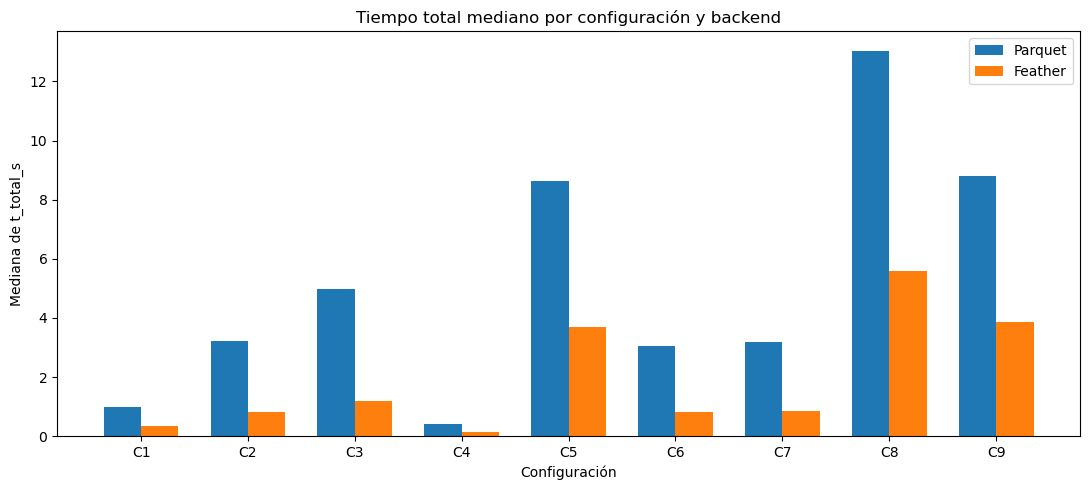

In [8]:
import matplotlib.pyplot as plt
import numpy as np

plot_df = summary[["config_id", "backend", "t_total_median"]].copy()
plot_df = plot_df.sort_values(["config_id", "backend"])

configs = sorted(plot_df["config_id"].unique())
x = np.arange(len(configs))
width = 0.35

parquet_vals = (
    plot_df[plot_df["backend"] == "parquet"]
    .set_index("config_id")
    .loc[configs, "t_total_median"]
    .values
)

feather_vals = (
    plot_df[plot_df["backend"] == "feather"]
    .set_index("config_id")
    .loc[configs, "t_total_median"]
    .values
)

plt.figure(figsize=(11, 5))
plt.bar(x - width/2, parquet_vals, width, label="Parquet")
plt.bar(x + width/2, feather_vals, width, label="Feather")
plt.xticks(x, configs)
plt.xlabel("Configuración")
plt.ylabel("Mediana de t_total_s")
plt.title("Tiempo total mediano por configuración y backend")
plt.legend()
plt.tight_layout()
plt.show()

El gráfico confirma visualmente lo que ya sugería la tabla anterior: Feather mantiene menores tiempos totales en todas las configuraciones evaluadas. La diferencia no solo aparece en los escenarios más grandes, sino también en los intermedios y pequeños, lo que sugiere que la ventaja temporal no es un efecto aislado de un solo régimen de tamaño.

También se observa que la brecha absoluta crece en configuraciones más exigentes, como `C5`, `C8` y `C9`. Esto es importante, porque precisamente son esos escenarios los que más pesan al momento de decidir un backend por defecto para persistencia: allí donde el costo operativo empieza a ser relevante, Feather sigue conservando una ventaja clara de tiempo.

## 6. Score global y chequeo de la restricción de RAM

La decisión principal del experimento no se toma configuración por configuración de manera aislada, sino mediante:

- un Score_global promedio sobre las 9 configuraciones;
- más una restricción de RAM sobre los escenarios exigentes.

Aquí se calculan ambas cosas y se muestra la lógica de decisión.

In [18]:
score_global = comparison["score"].mean()

heavy_ram_check = comparison.loc[comparison["is_heavy"], ["config_id", "r_ram"]].copy()
heavy_ram_check["ram_constraint_pass"] = heavy_ram_check["r_ram"] <= 1.25

all_fidelity_pass = measured["fidelity_pass"].all()
all_status_pass = measured["status"].eq("PASS").all()
ram_constraint_global = heavy_ram_check["ram_constraint_pass"].all()

decision = (
    "feather"
    if all_fidelity_pass and all_status_pass and (score_global < 1.0) and ram_constraint_global
    else "parquet"
)

decision_table = pd.DataFrame(
    [
        {
            "all_fidelity_pass": all_fidelity_pass,
            "all_status_pass": all_status_pass,
            "score_global": score_global,
            "score_condition_pass": score_global < 1.0,
            "ram_constraint_global": ram_constraint_global,
            "recommended_backend": decision,
        }
    ]
)

display(decision_table)
display(heavy_ram_check)

heavy_ram_explained = heavy_ram_check.copy()
heavy_ram_explained["threshold"] = 1.25
heavy_ram_explained["margin_to_threshold"] = heavy_ram_explained["threshold"] - heavy_ram_explained["r_ram"]

def describe_ram_behavior(r):
    if r < 1:
        return "Feather usa menos RAM que Parquet"
    elif r <= 1.25:
        return "Feather usa más RAM, pero dentro del umbral"
    else:
        return "Feather supera el umbral permitido"

heavy_ram_explained["ram_behavior"] = heavy_ram_explained["r_ram"].apply(describe_ram_behavior)
heavy_ram_explained["margin_to_threshold"] = heavy_ram_explained["margin_to_threshold"].round(3)

display(heavy_ram_explained)

,all_fidelity_pass,all_status_pass,score_global,score_condition_pass,ram_constraint_global,recommended_backend
0,True,True,0.527444,True,True,feather


,config_id,r_ram,ram_constraint_pass
4,C5,0.982225,True
6,C7,0.973944,True
7,C8,0.986356,True
8,C9,0.982879,True


,config_id,r_ram,ram_constraint_pass,threshold,margin_to_threshold,ram_behavior
4,C5,0.982225,True,1.25,0.268,Feather usa menos RAM que Parquet
6,C7,0.973944,True,1.25,0.276,Feather usa menos RAM que Parquet
7,C8,0.986356,True,1.25,0.264,Feather usa menos RAM que Parquet
8,C9,0.982879,True,1.25,0.267,Feather usa menos RAM que Parquet


Aquí se materializa la regla de decisión completa del experimento. La primera tabla resume el resultado global:

- todas las runs medidas pasaron correctitud;
- todas quedaron en estado `PASS`;
- el `Score_global` obtenido fue `0.527444`, claramente menor que 1;
- y la restricción de RAM también se cumple.

La segunda tabla no entrega “puntos” al score, sino que implementa una restricción operativa. En el diseño del experimento, la RAM no se usa para premiar a un backend, sino para impedir que uno “gane” por tiempo y tamaño a costa de volver impracticable el pipeline en escenarios pesados. Para eso se definió `r_ram = peak_ram_feather / peak_ram_parquet` y se exigió `r_ram <= 1.25` en las configuraciones más exigentes.

En los resultados observados, `C5`, `C7`, `C8` y `C9` cumplen holgadamente esa condición. Más aún, en todos esos casos `r_ram < 1`, es decir, Feather no solo no empeora demasiado la memoria, sino que usa ligeramente menos peak RAM que Parquet. Por eso la RAM no impide el usoFeather y la decisión por score se mantiene.

## 6.1. Plano de comparación Feather vs Parquet: tiempo y tamaño

En este gráfico se representa cada configuración como un punto en el plano `(r_time, r_size)`, donde:

- `r_time < 1` implica que Feather fue más rápido que Parquet;
- `r_size < 1` implica que Feather generó un artefacto más pequeño que Parquet.

Las líneas de referencia en `x=1` e `y=1` separan los casos donde Feather mejora o empeora respecto de Parquet. Este gráfico resume de manera compacta la lógica comparativa usada en el score.

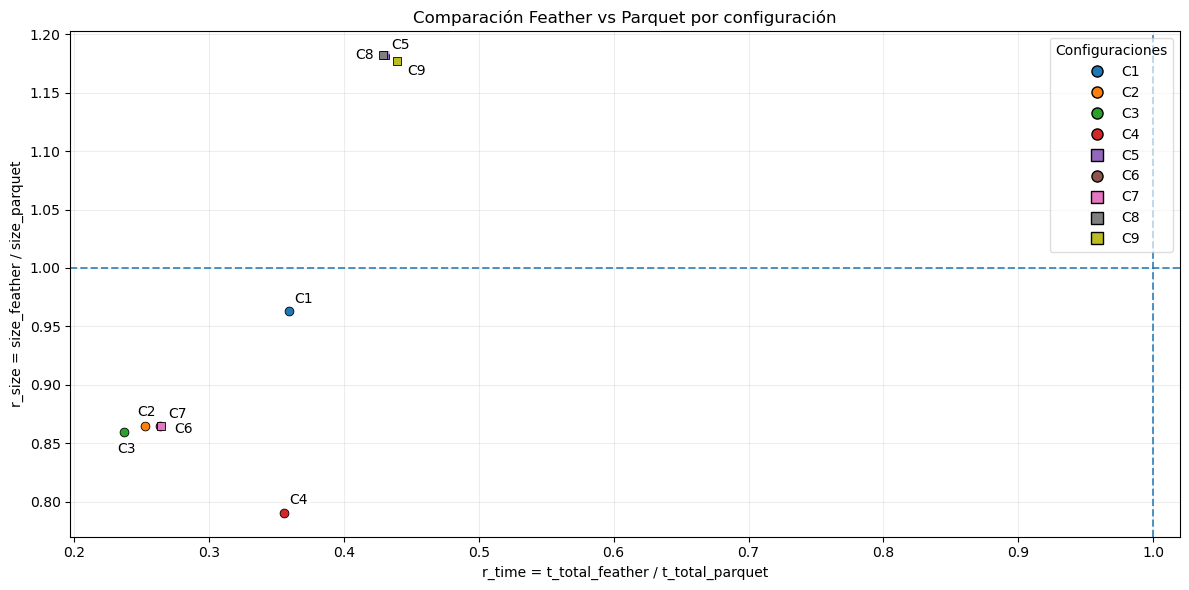

In [13]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D

plot_cmp = comparison.copy().sort_values("config_id").reset_index(drop=True)

# Colores distintos por configuración
cmap = plt.get_cmap("tab10")
colors = [cmap(i % 10) for i in range(len(plot_cmp))]

# Offsets manuales para evitar solapamientos de etiquetas
label_offsets = {
    "C1": (4, 6),
    "C2": (-6, 7),
    "C3": (-5, -15),
    "C4": (4, 6),
    "C5": (4, 4),
    "C6": (10, -5),
    "C7": (5, 6),
    "C8": (-20, -3),
    "C9": (8, -10),
}

plt.figure(figsize=(12, 6))

# Dibujar puntos
for i, row in plot_cmp.iterrows():
    marker = "s" if row["is_heavy"] else "o"
    plt.scatter(
        row["r_time"],
        row["r_size"],
        color=colors[i],
        s=40,
        marker=marker,
        edgecolors="black",
        linewidths=0.6,
        zorder=3,
    )

# Etiquetas de puntos
for i, row in plot_cmp.iterrows():
    dx, dy = label_offsets.get(row["config_id"], (8, 6))
    plt.annotate(
        row["config_id"],
        (row["r_time"], row["r_size"]),
        xytext=(dx, dy),
        textcoords="offset points",
        fontsize=10,
        bbox=dict(
            boxstyle="round,pad=0.18",
            fc="white",
            ec="none",
            alpha=0.82,
        ),
        zorder=4,
    )

# Líneas de referencia Feather = Parquet
plt.axvline(1.0, linestyle="--", linewidth=1.4, alpha=0.8)
plt.axhline(1.0, linestyle="--", linewidth=1.4, alpha=0.8)

plt.xlabel("r_time = t_total_feather / t_total_parquet")
plt.ylabel("r_size = size_feather / size_parquet")
plt.title("Comparación Feather vs Parquet por configuración")

# Márgenes
x_min = min(plot_cmp["r_time"].min() - 0.04, 0.20)
x_max = max(plot_cmp["r_time"].max() + 0.10, 1.02)
y_min = min(plot_cmp["r_size"].min() - 0.02, 0.77)
y_max = max(plot_cmp["r_size"].max() + 0.02, 1.20)

plt.xlim(x_min, x_max)
plt.ylim(y_min, y_max)

# Leyenda: una entrada por configuración (color + forma), dentro del gráfico
legend_elements = []
for i, row in plot_cmp.iterrows():
    marker = "s" if row["is_heavy"] else "o"
    legend_elements.append(
        Line2D(
            [0], [0],
            marker=marker,
            color="w",
            label=row["config_id"],
            markerfacecolor=colors[i],
            markeredgecolor="black",
            markersize=8,
        )
    )

plt.legend(
    handles=legend_elements,
    title="Configuraciones",
    loc="upper right",
    frameon=True,
    framealpha=0.65,
    fancybox=True,
)

plt.grid(alpha=0.22)
plt.tight_layout()
plt.show()

Este gráfico resume muy bien el patrón global del experimento. Todos los puntos quedan a la izquierda de `x = 1`, lo que indica que Feather fue más rápido que Parquet en todas las configuraciones. En cambio, la dimensión vertical muestra un comportamiento mixto: la mayoría de los puntos queda bajo `y = 1`, pero `C5`, `C8` y `C9` quedan sobre esa línea, reflejando que en esos escenarios pesados Parquet logra artefactos más compactos.

La lectura conjunta del plano es importante: no existe ninguna configuración donde Feather sea más lento que Parquet, mientras que la desventaja de Feather se concentra solo en tamaño y solo en algunos casos grandes. Eso explica por qué el score global termina favoreciendo a Feather: la mejora temporal es global, mientras que la penalización en tamaño es acotada a un subconjunto de escenarios.

## 7. Escenarios de referencia: caso típico y caso exigente

El diseño del experimento definió dos escenarios especialmente útiles para interpretar resultados:

- **Típico**: `C2 = (200k, 156, k=10)`
- **Exigente**: `C9 = (1M, 156, k=10k)`

Aquí se extraen ambos casos para compararlos directamente entre Parquet y Feather.

In [11]:
reference_configs = ["C2", "C9"]

reference_summary = summary.loc[summary["config_id"].isin(reference_configs)].copy()
reference_summary = reference_summary.sort_values(["config_id", "backend"])

display(
    reference_summary[
        [
            "config_id", "backend",
            "n_rows", "n_cols", "k",
            "t_total_median", "t_total_iqr",
            "size_total_median", "size_total_iqr",
            "peak_ram_median", "peak_ram_iqr",
        ]
    ]
)

display(comparison.loc[comparison["config_id"].isin(reference_configs)])

,config_id,backend,n_rows,n_cols,k,t_total_median,t_total_iqr,size_total_median,size_total_iqr,peak_ram_median,peak_ram_iqr
2,C2,feather,200000,156,10,0.813640,0.004048,117319897.0,0.0,675.546875,5.335937
3,C2,parquet,200000,156,10,3.218816,0.054691,135640987.0,0.0,698.292969,4.636718
16,C9,feather,1000000,156,10000,3.858509,0.022252,588487910.0,0.0,3019.339844,0.339844
17,C9,parquet,1000000,156,10000,8.789256,0.080108,499922754.0,0.0,3071.933594,0.621094


,config_id,n_rows,n_cols,k,is_heavy,t_total_parquet,t_total_feather,size_parquet,size_feather,ram_parquet,ram_feather,r_time,r_size,score,r_ram,time_winner,size_winner,score_winner
1,C2,200000,156,10,False,3.218816,0.813640,135640987.0,117319897.0,698.292969,675.546875,0.252776,0.864930,0.436422,0.967426,feather,feather,feather
8,C9,1000000,156,10000,True,8.789256,3.858509,499922754.0,588487910.0,3071.933594,3019.339844,0.439003,1.177158,0.660449,0.982879,feather,parquet,feather


Estas tablas cumplen un rol interpretativo: permiten resumir el experimento completo en dos escenarios particulares, uno representativo del uso corriente y otro cercano al peor caso operacional.

En el **caso típico (`C2`)**, Feather presenta una ventaja muy marcada: reduce el tiempo total desde `3.218816 s` a `0.813640 s`, genera un artefacto más pequeño y además usa algo menos de RAM. Es decir, en el escenario más representativo del uso esperado del módulo, Feather domina simultáneamente en tiempo, tamaño y memoria.

En el **caso exigente (`C9`)**, el comportamiento es más interesante. Feather sigue siendo claramente más rápido (`3.858509 s` versus `8.789256 s`) y mantiene una RAM algo menor, pero Parquet logra un artefacto más compacto en disco. Este caso es valioso porque deja explícito el trade-off real del experimento: en escenarios pesados, el costo de almacenamiento puede favorecer a Parquet, aunque la ventaja temporal de Feather siga siendo suficientemente grande como para inclinar el score a su favor.

Por eso estos dos escenarios no reemplazan el análisis global, pero sí lo aterrizan: `C2` muestra el caso base donde Feather gana de forma completa, mientras que `C9` muestra el caso exigente donde Feather gana por rendimiento, aunque Parquet conserve una fortaleza específica en tamaño.

## 8. Tabla final 

Se construye una tabla final compacta, pensada para usarla como tabla de resultados principales.

La idea es dejar por configuración:

- medianas por backend,
- ratios Feather/Parquet,
- score,
- ratio de RAM,
- backend ganador por score.

In [12]:
final_table = comparison[
    [
        "config_id", "n_rows", "n_cols", "k", "is_heavy",
        "t_total_parquet", "t_total_feather", "r_time",
        "size_parquet", "size_feather", "r_size",
        "ram_parquet", "ram_feather", "r_ram",
        "score", "score_winner",
    ]
].copy()

# Opcional: redondeo para lectura humana
final_table["t_total_parquet"] = final_table["t_total_parquet"].round(6)
final_table["t_total_feather"] = final_table["t_total_feather"].round(6)
final_table["r_time"] = final_table["r_time"].round(3)
final_table["size_parquet"] = final_table["size_parquet"].round(0).astype(int)
final_table["size_feather"] = final_table["size_feather"].round(0).astype(int)
final_table["r_size"] = final_table["r_size"].round(3)
final_table["ram_parquet"] = final_table["ram_parquet"].round(3)
final_table["ram_feather"] = final_table["ram_feather"].round(3)
final_table["r_ram"] = final_table["r_ram"].round(3)
final_table["score"] = final_table["score"].round(3)

display(final_table)

,config_id,n_rows,n_cols,k,is_heavy,t_total_parquet,t_total_feather,r_time,size_parquet,size_feather,r_size,ram_parquet,ram_feather,r_ram,score,score_winner
0,C1,200000,36,10,False,0.994210,0.357234,0.359,31459110,30301524,0.963,335.688,319.578,0.952,0.540,feather
1,C2,200000,156,10,False,3.218816,0.813640,0.253,135640987,117319897,0.865,698.293,675.547,0.967,0.436,feather
2,C3,200000,256,10,False,4.993842,1.184043,0.237,220817724,189835423,0.860,996.129,979.234,0.983,0.424,feather
3,C4,20000,156,10,False,0.403034,0.143207,0.355,14981886,11842335,0.790,157.641,154.223,0.978,0.486,feather
4,C5,1000000,156,10,True,8.617351,3.710191,0.431,495691672,586221411,1.183,3060.219,3005.824,0.982,0.656,feather
5,C6,200000,156,1000,False,3.065650,0.808093,0.264,135827356,117497827,0.865,700.379,677.375,0.967,0.444,feather
6,C7,200000,156,10000,True,3.170950,0.839115,0.265,137708742,119073644,0.865,707.008,688.586,0.974,0.445,feather
7,C8,1000000,256,10,True,13.043244,5.597942,0.429,802461331,948588945,1.182,4556.754,4494.582,0.986,0.655,feather
8,C9,1000000,156,10000,True,8.789256,3.858509,0.439,499922754,588487910,1.177,3071.934,3019.340,0.983,0.660,feather


La tabla final condensa la decisión del experimento en una sola vista. Se observa que:

- `score_winner = feather` en las 9 configuraciones;
- `r_time` se mantiene siempre muy por debajo de 1, mostrando que Feather fue sistemáticamente más rápido;
- `r_ram` también permanece por debajo de 1 en todos los casos, por lo que no aparece una penalización de memoria;
- `r_size` es el único indicador donde Parquet supera a Feather en algunos escenarios pesados (`C5`, `C8`, `C9`).

En términos prácticos, esta tabla muestra que el experimento no termina en un empate difuso: la evidencia es suficientemente consistente como para recomendar Feather como opción por defecto. Al mismo tiempo, también deja visible por qué tiene sentido conservar Parquet como alternativa disponible: en cargas grandes, puede seguir siendo preferible cuando la prioridad principal del usuario sea minimizar tamaño en disco.

Además, esta decisión no se apoya solo en medianas favorables, sino también en un comportamiento estable entre repeticiones. La revisión previa del IQR mostró que las métricas de tiempo, tamaño y RAM presentan una dispersión baja o moderada en prácticamente todos los casos, por lo que la ventaja observada para Feather no parece depender de corridas atípicas, sino de un patrón suficientemente consistente para sustentar una decisión de diseño.

## 8.1. Contraste con la hipótesis del experimento

La hipótesis general del experimento fue que Feather podría reducir los tiempos de lectura y escritura end-to-end, manteniendo fidelidad del roundtrip, tamaño aceptable y sin disparar el uso de memoria a niveles imprácticos.

Por lo visto en bloques anteriores, permiten afirmar que la hipótesis general sí queda respaldada. Feather redujo de manera consistente los tiempos end-to-end, mantuvo correctitud en todas las corridas medidas y no generó un deterioro problemático de memoria en los escenarios exigentes.

La parte más matizada de la hipótesis aparece en el tamaño: Feather no fue siempre el formato más compacto, ya que Parquet resultó mejor en almacenamiento en algunos casos pesados. Sin embargo, esa desventaja parcial no fue suficiente para revertir la conclusión general, porque el criterio del experimento exigía un tamaño aceptable, no necesariamente mínimo en todos los casos. Bajo esa formulación, los resultados sí son consistentes con la hipótesis inicial.

## 9. Decisión final del experimento

El resultado del experimento permite seleccionar a **Feather** como backend recomendado bajo la regla de decisión definida. Esta decisión se sustenta en tres hechos simultáneos:

1. **Correctitud**: todas las corridas medidas completaron correctamente y pasaron la verificación de fidelidad.
2. **Desempeño global**: el `Score_global = 0.527444` quedó claramente por debajo de 1, lo que favorece a Feather en la combinación tiempo + tamaño.
3. **Viabilidad operativa**: la restricción de RAM en escenarios pesados también se cumplió, e incluso Feather mostró un peak RAM ligeramente menor que Parquet en todos los casos exigentes analizados.

En consecuencia, el experimento respalda dejar **Feather como backend por defecto** para la persistencia formal del módulo en el patrón actual de uso, donde el backend se emplea principalmente para operaciones de escritura y lectura, mientras el procesamiento posterior ocurre en memoria.

Sin embargo, esta decisión **no implica descartar Parquet**. Los resultados muestran que Parquet conserva una ventaja concreta en tamaño de almacenamiento en algunos escenarios pesados (`C5`, `C8`, `C9`). Por ello, mantener ambos backends disponibles sigue siendo una decisión razonable de diseño: Feather como opción por defecto por desempeño global, y Parquet como alternativa explícita para usuarios que prioricen compacidad en disco, compatibilidad con herramientas externas o facilidad de inspección del artefacto persistido.

Bajo esa lógica, la conclusión operativa no es “Parquet deja de servir”, sino más bien que Feather pasa a ser la opción recomendada por defecto, mientras que Parquet permanece como backend soportado y útil en escenarios donde sus fortalezas específicas sigan siendo relevantes.

## 10. Interpretación

Los resultados del experimento muestran una diferencia clara entre los dos formatos evaluados. En el patrón de uso definido para Golondrina y Pylondrina: persistencia file-based orientada principalmente a `write/read`, con procesamiento posterior en memoria, **Feather** ofrece una mejora consistente en tiempo total respecto de Parquet. Esta ventaja aparece en todas las configuraciones, incluyendo tanto los casos típicos como los escenarios más exigentes.

El experimento también muestra que la comparación no puede reducirse a una sola métrica. Aunque Feather domina en tiempo y cumple correctamente la restricción de RAM, Parquet conserva una fortaleza específica en compacidad de almacenamiento en algunos casos grandes. Esto es importante porque evita una lectura muy simple del resultado: el backend recomendado depende del objetivo principal. Si la prioridad es rendimiento end-to-end en lectura y escritura, Feather resulta más conveniente; si la prioridad es minimizar tamaño en disco o aprovechar un ecosistema más difundido para inspección y herramientas externas, Parquet sigue siendo una alternativa plenamente válida.

Desde el punto de vista del módulo, esta lectura justifica una decisión de diseño equilibrada: **mantener soporte para ambos formatos**, pero dejar Feather como backend por defecto. Esto permite capturar la ventaja empírica observada en el experimento sin perder interoperabilidad ni flexibilidad para usuarios que, por razones prácticas, prefieran seguir trabajando con Parquet. En ese sentido, el experimento no solo elige un “ganador”, sino que también orienta cómo debería quedar expuesta la persistencia en la API y en el visualizador del módulo: con un default respaldado por evidencia, pero sin eliminar la posibilidad de elección.